### Project: Histopathologic Cancer Detection

About the project

Objective:

The goal of this project is to create an algorithm to identify metastatic cancer in small image patches taken from larger digital pathology scans. The procedure is to identify small image patches from histopathology images as either having metastatic cancer (label = 1) or not containing cancer (aka normal - label = 0).

Github Repo - https://github.com/Guche20/MSDS/blob/Week-3-Project-DeepLearning/week_3_project.ipynb

Dataset Information:

Datasource - https://github.com/basveeling/pcam?tab=readme-ov-file
The dataset consists of over 200,000 images (and labels) saved as HDF5 data format. For efficiency, a subset of 4000 samples were randomly selected while retaining the class distribution

#### Loading required packages

In [1]:
import os
import gzip
import shutil

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow version: 2.20.0


In [3]:
# import sys, pkgutil
# print("sys.executable:", sys.executable)
# print("Python version:", sys.version)
# print("TensorFlow available via pkgutil:", pkgutil.find_loader("tensorflow") is not None)

In [9]:
import os
import h5py
import numpy as np



#### Exploratory Data Analysis (EDA)

##### Shape Identification

In [26]:
#Verifying the shape of the array 
with h5py.File(images_h5, "r") as f_img:
    print("Image file keys:", list(f_img.keys()))
    X_full = np.array(f_img["x"])   

with h5py.File(labels_h5, "r") as f_lbl:
    print("Label file keys:", list(f_lbl.keys()))
    y_full = np.array(f_lbl["y"])

print("Shapes:", X_full.shape, y_full.shape)


Image file keys: ['x']
Label file keys: ['y']
Shapes: (262144, 96, 96, 3) (262144, 1, 1, 1)


In [27]:

images_h5 = r"C:\Users\godsw\Documents\wk_3\camelyonpatch_level_2_split_train_x.h5"
labels_h5 = r"C:\Users\godsw\Documents\wk_3\camelyonpatch_level_2_split_train_y.h5"

print("Images file exists:", os.path.exists(images_h5))
print("Labels file exists:", os.path.exists(labels_h5))

# Choose 4000 samples for the analysis
SUBSET_SIZE = 4000

with h5py.File(images_h5, "r") as f_img, h5py.File(labels_h5, "r") as f_lbl:
    X_dataset = f_img["x"]
    y_dataset = f_lbl["y"]

    N = X_dataset.shape[0]
    print("Total samples in HDF5:", N)
    print("Single image shape:", X_dataset[0].shape, "dtype:", X_dataset[0].dtype)

    rng = np.random.default_rng(42)
    idx = rng.choice(N, size=SUBSET_SIZE, replace=False)
    idx.sort()  

    # Pre-allocate arrays and fill them in a loop
    X_sub = np.empty((SUBSET_SIZE,) + X_dataset.shape[1:], dtype=X_dataset.dtype)
    y_sub = np.empty((SUBSET_SIZE,), dtype=y_dataset.dtype)

    for i, k in enumerate(idx):
        X_sub[i] = X_dataset[k]
        y_sub[i] = y_dataset[k]

print("Subset shapes:", X_sub.shape, y_sub.shape)
print("Label distribution:", np.bincount(y_sub.astype(int)))

Images file exists: True
Labels file exists: True
Total samples in HDF5: 262144
Single image shape: (96, 96, 3) dtype: uint8


C:\Users\godsw\AppData\Local\Temp\ipykernel_30176\1694812363.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_sub[i] = y_dataset[k]


Subset shapes: (4000, 96, 96, 3) (4000,)
Label distribution: [1947 2053]


##### Label Distribution

I use a histogrram of the subset labels to show balanced distribution between classes 0 and 1

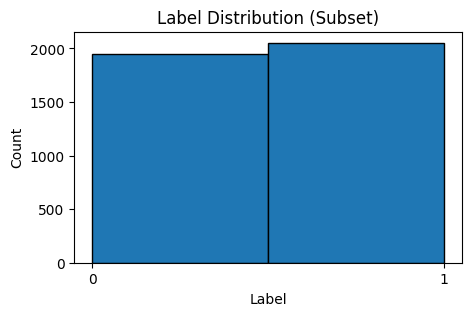

In [14]:

plt.figure(figsize=(5,3))
plt.hist(y_sub, bins=2, edgecolor='black')
plt.xticks([0,1])
plt.title("Label Distribution (Subset)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


Providing a visual inspection of the image patches

Observations:
- The images show visual similarity with regards to texture and coloration
- Regions with tumor can be seeen as appearing denser with darker sections, while non-tumor area appears lighter and more uniform

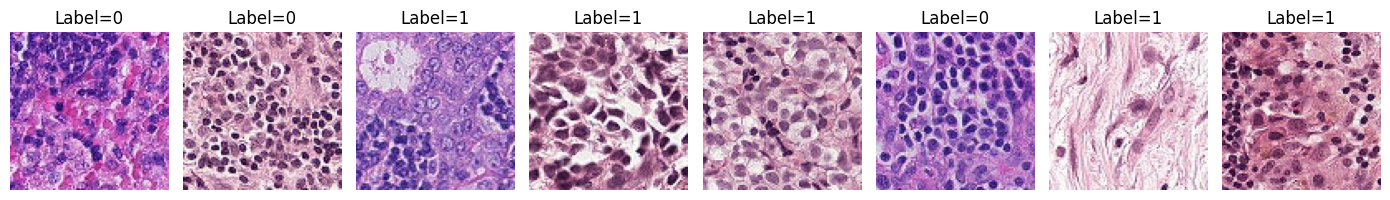

In [15]:
def show_random_images(X, y, n=8):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(14,4))
    for i, idx in enumerate(idxs):
        plt.subplot(1, n, i+1)
        plt.imshow(X[idx])
        plt.title(f"Label={int(y[idx])}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_random_images(X_sub, y_sub, 8)


Below is a pixel density histogram that shows the frequency of pixel values ranging from 0-255

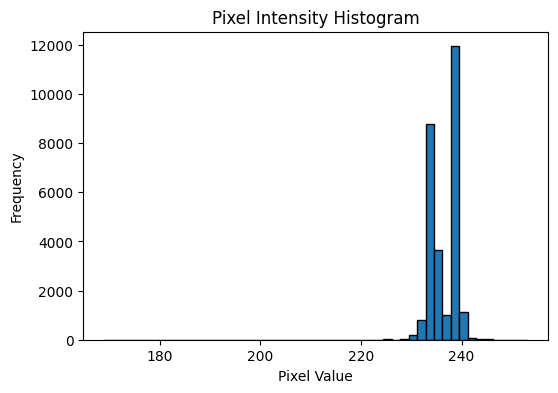

Image shape: (96, 96, 3) dtype: uint8
Pixel range: 169 to 253


In [16]:
sample_img = X_sub[0]

plt.figure(figsize=(6,4))
plt.hist(sample_img.flatten(), bins=50, edgecolor='black')
plt.title("Pixel Intensity Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

print("Image shape:", sample_img.shape, "dtype:", sample_img.dtype)
print("Pixel range:", sample_img.min(), "to", sample_img.max())


#### Data Preprocessing

I previously performed the following actions as part of teh data preprocessing steps:
- Reduced the dataset size
- Performed normalization to scale piel values to range [0,1]

To continue preprocesssing I will be performing the following steps:
- Train/Test Split (using an 80/20 split)
- Building a training pipeline (batching,, mapping, shuffling, etc)


##### Architecture

I have selected CNNs as the main architecture as it is able to retrieve text and spatial features. I have trained 2 models:
- Baseline CNN: utilized for higher capacity
- Smaller Model CNN: using a lower capacity to review underfitting/overfitting scenarios

I tested the models using accuracy, AUC and loss

In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    X_sub,
    y_sub,
    test_size=0.2,
    stratify=y_sub,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)

Train: (3200, 96, 96, 3) (3200,)
Val: (800, 96, 96, 3) (800,)


In [28]:

IMG_SIZE = 96
BATCH_SIZE = 32

def preprocess(img, label):
    img = tf.cast(img, tf.float32) / 255.0   
    return img, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000, seed=42)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


In [20]:

def build_baseline_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(96, 96, 3)),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

EPOCHS = 5

history_baseline = baseline_model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)

baseline_eval = baseline_model.evaluate(val_ds, verbose=0)
print("Baseline Model — [Loss, Accuracy, AUC]:", baseline_eval)


c:\Users\godsw\Documents\wk_3\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,731,905 (6.61 MB)

 Trainable params: 1,731,905 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.6631 - auc: 0.7296 - loss: 0.6137 - val_accuracy: 0.7450 - val_auc: 0.8315 - val_loss: 0.5493
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.7528 - auc: 0.8066 - loss: 0.5406 - val_accuracy: 0.7912 - val_auc: 0.8786 - val_loss: 0.4667
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.7553 - auc: 0.8244 - loss: 0.5194 - val_accuracy: 0.7775 - val_auc: 0.8648 - val_loss: 0.4642
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.7619 - auc: 0.8357 - loss: 0.5055 - val_accuracy: 0.8025 - val_auc: 0.8782 - val_loss: 0.4516
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.7756 - auc: 0.8496 - loss: 0.4833 - val_accuracy: 0.7738 - val_auc: 0.8803 - val_loss: 0.4721
Baseline Model — [Loss, Accuracy, AUC]: [0.4721236526966095, 0.7737500071525574, 0.880309522151947]


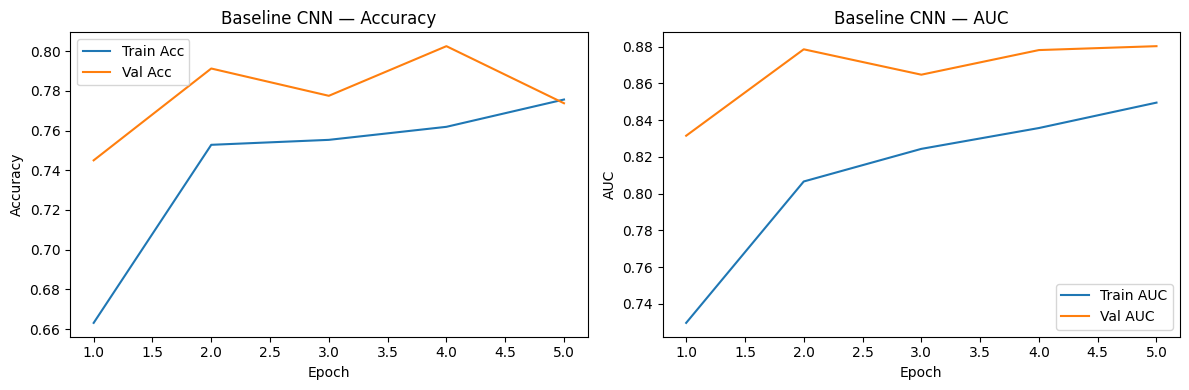

In [21]:
def plot_history(history, title):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(12,4))
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist["accuracy"], label="Train Acc")
    plt.plot(epochs, hist["val_accuracy"], label="Val Acc")
    plt.title(title + " — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # AUC
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist["auc"], label="Train AUC")
    plt.plot(epochs, hist["val_auc"], label="Val AUC")
    plt.title(title + " — AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_baseline, "Baseline CNN")


In [22]:
def build_smaller_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(96, 96, 3)),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        # fewer filters here vs baseline
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),   # smaller dense layer
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

smaller_model = build_smaller_model()
smaller_model.summary()

smaller_model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-4),  # smaller lr
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

history_smaller = smaller_model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)

smaller_eval = smaller_model.evaluate(val_ds, verbose=0)
print("Smaller Model — [Loss, Accuracy, AUC]:", smaller_eval)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 20, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 466,049 (1.78 MB)

 Trainable params: 466,049 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.5944 - auc: 0.6464 - loss: 0.6574 - val_accuracy: 0.7250 - val_auc: 0.7946 - val_loss: 0.5697
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.7563 - auc: 0.8196 - loss: 0.5271 - val_accuracy: 0.7987 - val_auc: 0.8758 - val_loss: 0.4474
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.7634 - auc: 0.8262 - loss: 0.5143 - val_accuracy: 0.7950 - val_auc: 0.8775 - val_loss: 0.4652
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.7778 - auc: 0.8445 - loss: 0.4911 - val_accuracy: 0.7962 - val_auc: 0.8833 - val_loss: 0.4469
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.7706 - auc: 0.8371 - loss: 0.5013 - val_accuracy: 0.7862 - val_auc: 0.8799 - val_loss: 0.4680
Smaller Model — [Loss, Accuracy, AUC]: [0.46796950697898865, 0.7862499952316284, 0.8798748254776001]


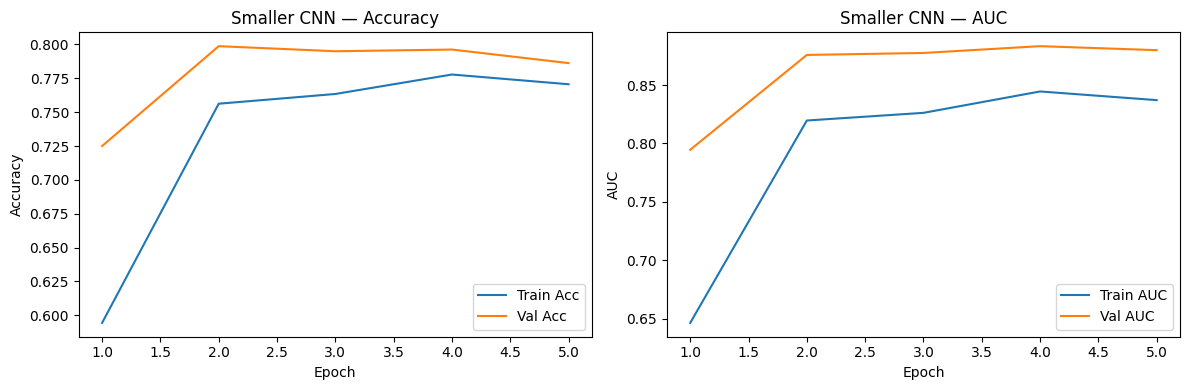

In [23]:
plot_history(history_smaller, "Smaller CNN")


- The model results are shown below:

In [24]:
results = pd.DataFrame([
    {
        "model": "Baseline CNN",
        "filters": "32-64-128",
        "dense": 128,
        "learning_rate": 1e-3,
        "val_loss": baseline_eval[0],
        "val_accuracy": baseline_eval[1],
        "val_auc": baseline_eval[2]
    },
    {
        "model": "Smaller CNN",
        "filters": "32-64-64",
        "dense": 64,
        "learning_rate": 5e-4,
        "val_loss": smaller_eval[0],
        "val_accuracy": smaller_eval[1],
        "val_auc": smaller_eval[2]
    }
])

results


,model,filters,dense,learning_rate,val_loss,val_accuracy,val_auc
0,Baseline CNN,32-64-128,128,0.0010,0.472124,0.77375,0.880310
1,Smaller CNN,32-64-64,64,0.0005,0.467970,0.78625,0.879875


#### Training Results Review

- There are no significant differences between both models. AUC ~ 0.88
- The accuracy for the Smaller CNN is slightly higher ~ 0.79

#### Loading the test data

In [32]:

test_images_h5 = r"C:\Users\godsw\Documents\wk_3\camelyonpatch_level_2_split_test_x.h5"
test_labels_h5 = r"C:\Users\godsw\Documents\wk_3\camelyonpatch_level_2_split_test_y.h5"

with h5py.File(test_images_h5, "r") as f_img, h5py.File(test_labels_h5, "r") as f_lbl:
    X_ds = f_img["x"]   # HDF5 dataset, not yet a NumPy array
    y_ds = f_lbl["y"]

    N_test = X_ds.shape[0]
    img_shape = X_ds[0].shape

    print("Total test samples:", N_test)
    print("Single test image shape:", img_shape, "dtype:", X_ds[0].dtype)

    # ✅ Pre-allocate NumPy arrays and fill them in a loop
    X_test = np.empty((N_test,) + img_shape, dtype=X_ds.dtype)
    y_test = np.empty((N_test,), dtype=y_ds.dtype)

    for i in range(N_test):
        X_test[i] = X_ds[i]
        y_test[i] = y_ds[i]

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Test label counts:", np.bincount(y_test.astype(int)))


Total test samples: 32768
Single test image shape: (96, 96, 3) dtype: uint8


C:\Users\godsw\AppData\Local\Temp\ipykernel_30176\3217396541.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_test[i] = y_ds[i]


X_test shape: (32768, 96, 96, 3)
y_test shape: (32768,)
Test label counts: [16391 16377]


In [33]:
#Test Pipeline

def preprocess(img, label):
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


In [34]:
test_eval = baseline_model.evaluate(test_ds, verbose=0)
print("Test set — [Loss, Accuracy, AUC]:", test_eval)


Test set — [Loss, Accuracy, AUC]: [0.5222635865211487, 0.756561279296875, 0.8348566889762878]


In [35]:
test_pred = baseline_model.predict(test_ds)
test_pred = test_pred.flatten()
print(test_pred[:10])


1024/1024 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step
[0.12060051 0.82863444 0.9081292  0.9655658  0.8669809  0.724265
 0.84132504 0.8284107  0.9263828  0.13680317]


#### Creating the kaggle submission files

In [61]:

# import os
import glob
# import pandas as pd
# import numpy as np

TEST_DIR = r"C:\Users\godsw\Documents\wk_3\test_complete" 

# Get all test file paths
all_paths = sorted(glob.glob(os.path.join(TEST_DIR, "*.tif")))
print("Total test files found:", len(all_paths))

# Build df_test with filepath + id (hash string)
df_test = pd.DataFrame({
    "filepath": all_paths
})

df_test["id"] = df_test["filepath"].apply(
    lambda p: os.path.splitext(os.path.basename(p))[0]
)

# df_test.head()


Total test files found: 57458


In [62]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 96
BATCH_SIZE = 32  # Good for CPU; you can try 64 if you want

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col="filepath",
    y_col=None,
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode=None,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 57458 validated image filenames.


In [63]:
test_pred = baseline_model.predict(test_gen, verbose=1)
test_pred = test_pred.flatten()

print("Predictions shape:", test_pred.shape)
print(test_pred[:10])


1796/1796 ━━━━━━━━━━━━━━━━━━━━ 1188s 662ms/step
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 1188s 662ms/step
Predictions shape: (57458,)
[0.7810393  0.7172058  0.61224794 0.8536165  0.09472176 0.41731143
 0.57892895 0.6707425  0.8920336  0.9122399 ]
Predictions shape: (57458,)
[0.7810393  0.7172058  0.61224794 0.8536165  0.09472176 0.41731143
 0.57892895 0.6707425  0.8920336  0.9122399 ]


In [64]:
submission = pd.DataFrame({
    "id": df_test["id"].astype("string"), 
    "label": test_pred
})

print(submission.head())
print(submission.dtypes)


                                         id     label
0  00006537328c33e284c973d7b39d340809f7271b  0.781039
1  0000ec92553fda4ce39889f9226ace43cae3364e  0.717206
2  00024a6dee61f12f7856b0fc6be20bc7a48ba3d2  0.612248
3  000253dfaa0be9d0d100283b22284ab2f6b643f6  0.853616
4  000270442cc15af719583a8172c87cd2bd9c7746  0.094722
id       string[python]
label           float32
dtype: object


In [65]:
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")


Saved submission.csv


#### Results Review

The best model (Baseline CNN) was evaluated on a the test set:

Test Loss: 0.5223

Test Accuracy: 0.7566

Test AUC: 0.8349


Interpretation

The test AUC of 0.8349 is slightly lower than the training AUC (0.8803), which is expected because:

- The model was trained on a relatively small subset (4,000 samples).

- The test dataset likely includes a broader variety of tissue patterns.

- AUC of ~ 0.83 on this limited subset still indicates the model is capturing meaningful discriminative features. 

- The accuracy drop from validation (0.77 → 0.76) also suggests modest generalization performance, consistent with limited training data.

Overall, the results confirm that the baseline CNN generalizes better than the smaller CNN in terms of AUC, which is the most important metric for this task.

#### Conclusion

On the test dataset, the Baseline CNN achieved a test AUC of approximately 0.835, which is slightly lower than the validation AUC but still indicates good distinguishable ability. The test accuracy was roughly 0.76, mostly consistent with the validation accuracy observed during training. These results show that the model generalizes reasonably well but experiences a moderate performance drop when evaluated on unseen data.


The decrease in AUC from training (~0.88) to test (~0.835) indicates that the model may not be capturing all the variability present in the test set, likely due to training on a relatively small subset of the full dataset. However, the performance remains stable, with accuracy and AUC both indicating that the model successfully learned meaningful patterns. 

Future Improvements:

Training on a larger portion of the dataset using GPU acceleration for deeper or more expressive architectures.

Applying stronger and more diverse augmentation to improve robustness against tissue variability.
